<a href="https://colab.research.google.com/github/Disha-kp/customer-retention-rfm-analysis/blob/main/Customer_Retention_%26_Cohort_Segmentation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import kagglehub
import pandas as pd

os.environ['KAGGLE_API_TOKEN'] = "KGAT_9870f22461c02d5c9202469ddd6bd503"

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Path to dataset files:", path)
import glob
csv_file = glob.glob(f"{path}/*.csv")[0]
df = pd.read_csv(csv_file)
df.head()

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df = df.dropna(subset=['Customer ID'])
print(f"Rows after removing missing customers ID:{len(df)}")

Rows after removing missing customers ID:824364


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 797885


In [ ]:
# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"Rows after removing returns/negative values: {len(df)}")

Rows after removing returns/negative values: 779425


In [ ]:
# Convert to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract just the YYYY-MM-DD date part
df['InvoiceDate'] = df['InvoiceDate'].dt.date

# Inspect the new column data type
print("Date column successfully standardized!")

Date column successfully standardized!


In [ ]:
# --- STEP 1: Remove missing Customer IDs ---
df_clean = df.dropna(subset=['Customer ID']).copy()

# --- STEP 2: Remove negative quantities and prices ---
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# --- STEP 3: Deduplicate duplicate rows ---
df_clean = df_clean.drop_duplicates()

# --- STEP 4: Standardize dates to YYYY-MM-DD ---
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']).dt.date

# --- STEP 5: Verify the cleaned data ---
print(f"Original row count: {len(df)}")
print(f"Cleaned row count:  {len(df_clean)}")
print("\nFirst 5 rows of cleaned data:")
df_clean.head()

Original row count: 779425
Cleaned row count:  779423

First 5 rows of cleaned data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.0,United Kingdom


In [ ]:
import os
import kagglehub
import pandas as pd
import glob
import duckdb

# 1. Set Kaggle Token & Download Dataset
os.environ['KAGGLE_API_TOKEN'] = "KGAT_9870f22461c02d5c9202469ddd6bd503"
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

# 2. Read CSV into df
csv_file = glob.glob(f"{path}/*.csv")[0]
df = pd.read_csv(csv_file)

# 3. Clean the Data into df_clean
df_clean = df.dropna(subset=['Customer ID']).copy()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
df_clean = df_clean.drop_duplicates()
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']).dt.date

# 4. Register df_clean with DuckDB
duckdb.register('df_clean', df_clean)

print("Raw 'df' loaded, 'df_clean' prepared, and DuckDB table registered.")

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Raw 'df' loaded, 'df_clean' prepared, and DuckDB table registered.


In [ ]:
sql_3c = """
WITH user_cohorts AS (
    SELECT
        "Customer ID" AS customer_id,
        DATE_TRUNC('month', CAST("InvoiceDate" AS DATE)) AS cohort_month
    FROM (
        SELECT
            "Customer ID",
            "InvoiceDate",
            ROW_NUMBER() OVER (PARTITION BY "Customer ID" ORDER BY "InvoiceDate") as rn
        FROM df_clean
    )
    WHERE rn = 1
),
cohort_offsets AS (
    SELECT
        t."Customer ID" AS customer_id,
        c.cohort_month,
        (EXTRACT(YEAR FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(MONTH FROM c.cohort_month)) AS month_offset
    FROM df_clean t
    JOIN user_cohorts c ON t."Customer ID" = c.customer_id
),
cohort_counts AS (
    SELECT
        cohort_month,
        month_offset,
        COUNT(DISTINCT customer_id) AS active_users
    FROM cohort_offsets
    GROUP BY cohort_month, month_offset
),
cohort_sizes AS (
    SELECT
        cohort_month,
        active_users AS total_cohort_users
    FROM cohort_counts
    WHERE month_offset = 0
)
SELECT
    c.cohort_month,
    c.month_offset,
    c.active_users,
    s.total_cohort_users,
    ROUND((c.active_users * 100.0 / s.total_cohort_users), 2) AS retention_percentage
FROM cohort_counts c
JOIN cohort_sizes s ON c.cohort_month = s.cohort_month
ORDER BY c.cohort_month, c.month_offset
"""

# 1. Run the query
retention_df = duckdb.sql(sql_3c).df()

# 2. Pivot into a Cohort Heatmap Grid
retention_matrix = retention_df.pivot(
    index='cohort_month',
    columns='month_offset',
    values='retention_percentage'
)

retention_matrix

month_offset,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12-01,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02-01,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03-01,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04-01,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05-01,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,...,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,...,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,...,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,...,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


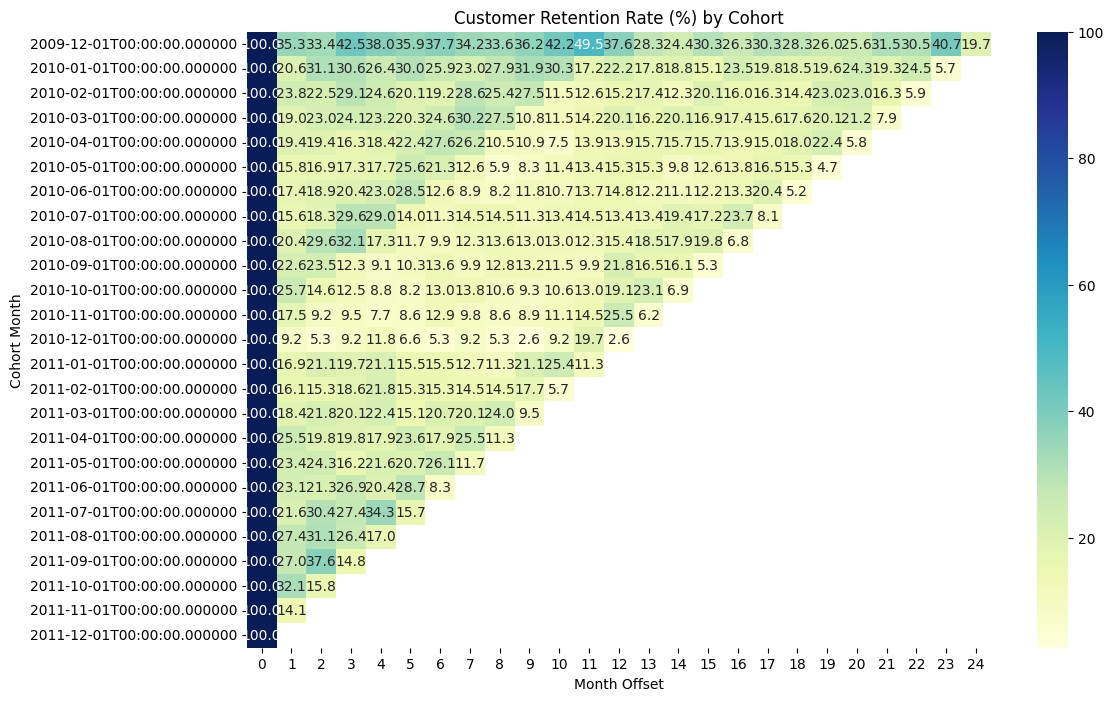

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Customer Retention Rate (%) by Cohort")
plt.xlabel("Month Offset")
plt.ylabel("Cohort Month")
plt.show()

In [ ]:
# --- STEP 4: RFM Segmentation ---

sql_rfm = """
WITH max_date AS (
    -- Reference date is 1 day after the latest purchase date in the dataset
    SELECT MAX(CAST("InvoiceDate" AS DATE)) + INTERVAL 1 DAY AS ref_date
    FROM df_clean
),
rfm_raw AS (
    SELECT
        t."Customer ID" AS customer_id,
        DATEDIFF('day', MAX(CAST(t."InvoiceDate" AS DATE)), m.ref_date) AS recency,
        COUNT(DISTINCT t."Invoice") AS frequency,
        ROUND(SUM(t."Quantity" * t."Price"), 2) AS monetary
    FROM df_clean t
    CROSS JOIN max_date m
    GROUP BY t."Customer ID", m.ref_date
)
SELECT
    customer_id,
    recency,
    frequency,
    monetary,
    -- Quartile scoring (1-4) for each metric
    NTILE(4) OVER (ORDER BY recency DESC) AS r_score,     -- Lower recency = higher score (4 is best)
    NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,     -- Higher frequency = higher score (4 is best)
    NTILE(4) OVER (ORDER BY monetary ASC) AS m_score       -- Higher spend = higher score (4 is best)
FROM rfm_raw
"""

rfm_df = duckdb.sql(sql_rfm).df()

# Combine scores into an RFM Score and Segment
rfm_df['rfm_score'] = rfm_df['r_score'].astype(str) + rfm_df['f_score'].astype(str) + rfm_df['m_score'].astype(str)

def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r == 4 and f == 4:
        return 'Champions / Best Customers'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Promising / Recent Buyers'
    elif r == 2 and f >= 3:
        return 'At Risk / Need Attention'
    elif r == 1:
        return 'Lost / Inactive'
    else:
        return 'Others'

rfm_df['segment'] = rfm_df.apply(assign_segment, axis=1)

# Display summary count per segment
segment_summary = rfm_df['segment'].value_counts().reset_index()
segment_summary.columns = ['Customer Segment', 'Count']
segment_summary

,Customer Segment,Count
0,Lost / Inactive,1470
1,Loyal Customers,1410
2,Others,897
3,Champions / Best Customers,776
4,Promising / Recent Buyers,752
5,At Risk / Need Attention,573


/tmp/ipykernel_2697/3283311215.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='Count', y='Customer Segment', palette='viridis')


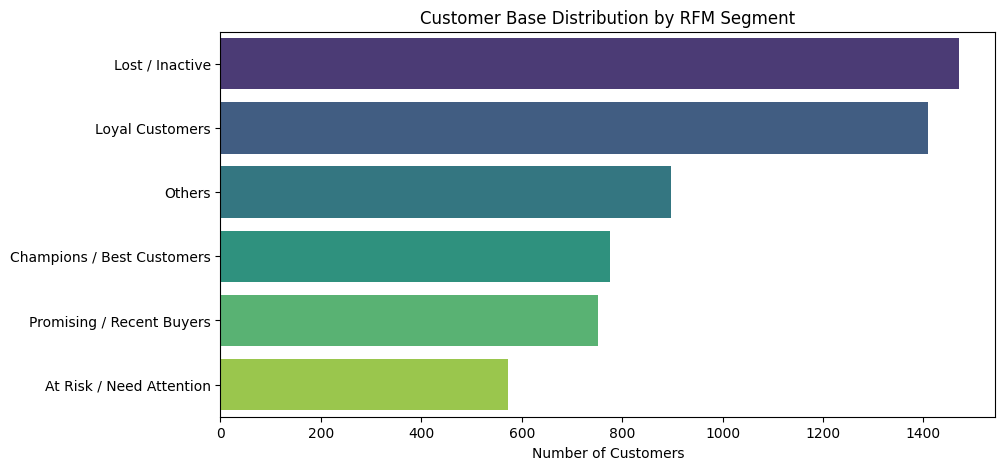

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x='Count', y='Customer Segment', palette='viridis')
plt.title("Customer Base Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("")
plt.show()

In [ ]:
# --- Executive KPI Summary ---
summary_kpis = duckdb.sql("""
SELECT
    COUNT(DISTINCT "Customer ID") AS total_unique_customers,
    COUNT(DISTINCT "Invoice") AS total_orders,
    ROUND(SUM("Quantity" * "Price"), 2) AS total_revenue,
    ROUND(SUM("Quantity" * "Price") / COUNT(DISTINCT "Invoice"), 2) AS avg_order_value,
    ROUND(SUM("Quantity" * "Price") / COUNT(DISTINCT "Customer ID"), 2) AS avg_revenue_per_user
FROM df_clean
""").df()

print("==========================================")
print("       EXECUTIVE SUMMARY METRICS          ")
print("==========================================")
summary_kpis

       EXECUTIVE SUMMARY METRICS          


,total_unique_customers,total_orders,total_revenue,avg_order_value,avg_revenue_per_user
0,5878,36969,17374804.27,469.98,2955.9


In [ ]:
import duckdb

sql_rfm_5 = """
WITH max_date AS (
    -- Reference date is 1 day after the latest purchase date
    SELECT MAX(CAST("InvoiceDate" AS DATE)) + INTERVAL 1 DAY AS ref_date
    FROM df_clean
),
rfm_raw AS (
    SELECT
        t."Customer ID" AS customer_id,
        DATEDIFF('day', MAX(CAST(t."InvoiceDate" AS DATE)), m.ref_date) AS recency,
        COUNT(DISTINCT t."Invoice") AS frequency,
        ROUND(SUM(t."Quantity" * t."Price"), 2) AS monetary
    FROM df_clean t
    CROSS JOIN max_date m
    GROUP BY t."Customer ID", m.ref_date
)
SELECT
    customer_id,
    recency,
    frequency,
    monetary,
    -- Percentile scoring (1 to 5)
    NTILE(5) OVER (ORDER BY recency DESC) AS r_score,     -- Lower recency = higher score (5 is best)
    NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,     -- Higher frequency = higher score (5 is best)
    NTILE(5) OVER (ORDER BY monetary ASC) AS m_score       -- Higher spend = higher score (5 is best)
FROM rfm_raw
"""

rfm_df = duckdb.sql(sql_rfm_5).df()

# Display the first few rows to verify 1-5 scores
rfm_df.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score
0,14095.0,723,1,2.95,1,1,1
1,13788.0,506,1,3.75,1,1,1
2,16738.0,298,1,3.75,2,1,1
3,14792.0,64,1,6.20,3,2,1
4,15913.0,535,1,6.30,1,1,1


In [ ]:
# Function to map 1-5 R-F-M scores to your specific strategic groups
def assign_exact_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    # Champions (R: 4-5, F: 4-5, M: 4-5)
    if r in [4, 5] and f in [4, 5] and m in [4, 5]:
        return 'Champions'

    # At Risk (R: 1-2, F: 4-5, M: 4-5)
    elif r in [1, 2] and f in [4, 5] and m in [4, 5]:
        return 'At Risk'

    # Recent Customers (R: 4-5, F: 1, M: 1-2)
    elif r in [4, 5] and f == 1 and m in [1, 2]:
        return 'Recent Customers'

    # Lost / Dormant (R: 1, F: 1, M: 1)
    elif r == 1 and f == 1 and m == 1:
        return 'Lost / Dormant'

    # Other intermediate customer groups
    else:
        return 'Needs Attention / Others'

# Apply the segment function to your NTILE(5) dataframe
rfm_df['segment'] = rfm_df.apply(assign_exact_segment, axis=1)

# View customer breakdown across your defined groups
segment_counts = rfm_df['segment'].value_counts().reset_index()
segment_counts.columns = ['Strategic Group', 'Customer Count']
segment_counts

,Strategic Group,Customer Count
0,Needs Attention / Others,3896
1,Champions,1339
2,Lost / Dormant,445
3,At Risk,198


In [ ]:
# Quick Python Plotly Heatmap (Interactive)
import plotly.express as px

fig = px.imshow(
    retention_matrix,
    labels=dict(x="Month Offset", y="Cohort Month", color="Retention %"),
    x=retention_matrix.columns,
    y=retention_matrix.index.astype(str),
    text_auto=".1f",
    color_continuous_scale="YlGnBu"
)
fig.update_layout(title="12-Month Cohort Retention Matrix")
fig.show()

In [ ]:
# Save your cleaned and processed datasets to CSV files in Colab
df_clean.to_csv('cleaned_retail_data.csv', index=False)
rfm_df.to_csv('rfm_segmented_data.csv', index=False)

print(" CSV files successfully generated and saved to Colab storage!")

 CSV files successfully generated and saved to Colab storage!


In [1]:
# Install libraries for visualization and web dashboarding in Colab
!pip install dash pandas plotly jupyter-dash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.1 MB/s eta 0:00:00


In [15]:
import pandas as pd
import duckdb
import plotly.express as px
import plotly.io as pio
import ipywidgets as widgets
from ipywidgets import Layout, VBox, HBox, Output

# Force Plotly to use Colab's native rendering mode
pio.renderers.default = "colab"

# Data Preparation
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
if 'Description' in df_clean.columns:
    df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.title()
if 'Country' in df_clean.columns:
    df_clean['Country'] = df_clean['Country'].astype(str).str.strip()

# Prepare Dropdown Choices
country_opts = ['All'] + sorted([str(c) for c in df_clean['Country'].dropna().unique()]) if 'Country' in df_clean.columns else ['All']
category_opts = ['All'] + sorted([str(p) for p in df_clean['Description'].dropna().unique() if len(str(p)) > 2])[:200] if 'Description' in df_clean.columns else ['All']

min_d = df_clean['InvoiceDate'].min().date()
max_d = df_clean['InvoiceDate'].max().date()

# Slicer Controls
w_country = widgets.Dropdown(options=country_opts, value='All', description='Location:', layout=Layout(width='280px'))
w_category = widgets.Dropdown(options=category_opts, value='All', description='Product:', layout=Layout(width='280px'))
w_start = widgets.DatePicker(value=min_d, description='Start Date:', layout=Layout(width='240px'))
w_end = widgets.DatePicker(value=max_d, description='End Date:', layout=Layout(width='240px'))

out_area = Output()

def render_dashboard(change=None):
    with out_area:
        out_area.clear_output(wait=True)

        c_val = w_country.value
        p_val = w_category.value
        s_val = w_start.value
        e_val = w_end.value

        # Filter Data
        f_df = df_clean.copy()
        if s_val and e_val:
            f_df = f_df[(f_df['InvoiceDate'].dt.date >= s_val) & (f_df['InvoiceDate'].dt.date <= e_val)]
        if c_val != 'All':
            f_df = f_df[f_df['Country'] == c_val]
        if p_val != 'All':
            f_df = f_df[f_df['Description'] == p_val]

        if f_df.empty:
            print("⚠️ No data available matching selected slicers. Please adjust filters.")
            return

        duckdb.register('f_df', f_df)

        # -------------------------------------------------------------
        # 1. HEATMAP VISUAL: Cohort Retention Matrix (12-Month Drop-off)
        # -------------------------------------------------------------
        cohort_sql = """
        WITH user_cohorts AS (
            SELECT "Customer ID" AS customer_id, DATE_TRUNC('month', CAST("InvoiceDate" AS DATE)) AS cohort_month
            FROM (SELECT "Customer ID", "InvoiceDate", ROW_NUMBER() OVER (PARTITION BY "Customer ID" ORDER BY "InvoiceDate") as rn FROM f_df) WHERE rn = 1
        ),
        cohort_offsets AS (
            SELECT t."Customer ID" AS customer_id, c.cohort_month,
                (EXTRACT(YEAR FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
                (EXTRACT(MONTH FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(MONTH FROM c.cohort_month)) AS month_offset
            FROM f_df t JOIN user_cohorts c ON t."Customer ID" = c.customer_id
        ),
        cohort_counts AS (
            SELECT cohort_month, month_offset, COUNT(DISTINCT customer_id) AS active_users
            FROM cohort_offsets WHERE month_offset <= 12 GROUP BY cohort_month, month_offset
        ),
        cohort_sizes AS (
            SELECT cohort_month, active_users AS total_users FROM cohort_counts WHERE month_offset = 0
        )
        SELECT c.cohort_month, c.month_offset, ROUND((c.active_users * 100.0 / s.total_users), 1) AS retention_pct
        FROM cohort_counts c JOIN cohort_sizes s ON c.cohort_month = s.cohort_month ORDER BY c.cohort_month, c.month_offset
        """
        ret_df = duckdb.sql(cohort_sql).df()
        if not ret_df.empty:
            ret_df['cohort_month'] = ret_df['cohort_month'].astype(str)
            piv = ret_df.pivot(index='cohort_month', columns='month_offset', values='retention_pct')
            fig1 = px.imshow(piv, labels=dict(x="Month Offset (0-12)", y="Cohort Month", color="Retention (%)"),
                             text_auto=True, aspect="auto", color_continuous_scale="Viridis",
                             title="<b>1. Heatmap Visual: Cohort Retention Matrix</b>")
            fig1.show(renderer="colab")

        # -------------------------------------------------------------
        # 2 & 3. TREEMAP & SCATTER VISUALS
        # -------------------------------------------------------------
        rfm_sql = """
        WITH max_date AS (SELECT MAX(CAST("InvoiceDate" AS DATE)) + INTERVAL 1 DAY AS ref_date FROM f_df),
        rfm_raw AS (
            SELECT t."Customer ID" AS customer_id,
                DATEDIFF('day', MAX(CAST(t."InvoiceDate" AS DATE)), m.ref_date) AS recency,
                COUNT(DISTINCT t."Invoice") AS frequency,
                ROUND(SUM(t."Quantity" * t."Price"), 2) AS monetary
            FROM f_df t CROSS JOIN max_date m GROUP BY t."Customer ID", m.ref_date
        )
        SELECT *, NTILE(5) OVER (ORDER BY recency DESC) AS r, NTILE(5) OVER (ORDER BY frequency ASC) AS f, NTILE(5) OVER (ORDER BY monetary ASC) AS m FROM rfm_raw
        """
        rfm = duckdb.sql(rfm_sql).df()

        def seg_map(r):
            if r['r'] in [4,5] and r['f'] in [4,5]: return 'Champions'
            elif r['r'] in [1,2] and r['f'] in [4,5]: return 'At Risk'
            elif r['r'] in [4,5] and r['f'] == 1: return 'Recent Customers'
            elif r['r'] == 1 and r['f'] == 1: return 'Lost / Dormant'
            else: return 'Others'

        rfm['segment'] = rfm.apply(seg_map, axis=1)

        # Treemap
        seg_sum = rfm.groupby('segment').agg(count=('customer_id', 'count'), revenue=('monetary', 'sum')).reset_index()
        fig2 = px.treemap(seg_sum, path=['segment'], values='revenue', color='count', color_continuous_scale='Blues',
                          title="<b>2. Treemap Visual: Customer Count & Revenue Breakdown</b>", hover_data=['count', 'revenue'])
        fig2.show(renderer="colab")

        # Scatter Plot
        fig3 = px.scatter(rfm, x='recency', y='monetary', color='segment', size='frequency', hover_data=['customer_id'],
                          title="<b>3. Scatter Visual: Recency vs Monetary Spend Across Segments</b>", labels={'recency':'Recency (Days)','monetary':'Monetary ($)'})
        fig3.show(renderer="colab")

# Connect Slicer Controls
w_country.observe(render_dashboard, names='value')
w_category.observe(render_dashboard, names='value')
w_start.observe(render_dashboard, names='value')
w_end.observe(render_dashboard, names='value')

# Display Dashboard Layout
display(VBox([HBox([w_country, w_category]), HBox([w_start, w_end])]), out_area)
render_dashboard()

Output()

In [11]:
import plotly.express as px
import duckdb

# Register cleaned dataframe
duckdb.register('df_clean', df_clean)

# ==========================================
# 1. HEATMAP: 12-MONTH COHORT RETENTION MATRIX
# ==========================================
cohort_query = """
WITH user_cohorts AS (
    SELECT
        "Customer ID" AS customer_id,
        DATE_TRUNC('month', CAST("InvoiceDate" AS DATE)) AS cohort_month
    FROM (
        SELECT "Customer ID", "InvoiceDate",
               ROW_NUMBER() OVER (PARTITION BY "Customer ID" ORDER BY "InvoiceDate") as rn
        FROM df_clean
    ) WHERE rn = 1
),
cohort_offsets AS (
    SELECT
        t."Customer ID" AS customer_id,
        c.cohort_month,
        (EXTRACT(YEAR FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(YEAR FROM c.cohort_month)) * 12 +
        (EXTRACT(MONTH FROM CAST(t."InvoiceDate" AS DATE)) - EXTRACT(MONTH FROM c.cohort_month)) AS month_offset
    FROM df_clean t
    JOIN user_cohorts c ON t."Customer ID" = c.customer_id
),
cohort_counts AS (
    SELECT cohort_month, month_offset, COUNT(DISTINCT customer_id) AS active_users
    FROM cohort_offsets
    WHERE month_offset <= 12
    GROUP BY cohort_month, month_offset
),
cohort_sizes AS (
    SELECT cohort_month, active_users AS total_cohort_users
    FROM cohort_counts WHERE month_offset = 0
)
SELECT
    c.cohort_month, c.month_offset,
    ROUND((c.active_users * 100.0 / s.total_cohort_users), 1) AS retention_percentage
FROM cohort_counts c
JOIN cohort_sizes s ON c.cohort_month = s.cohort_month
ORDER BY c.cohort_month, c.month_offset
"""
retention_df = duckdb.sql(cohort_query).df()
retention_df['cohort_month'] = retention_df['cohort_month'].astype(str)
pivot_df = retention_df.pivot(index='cohort_month', columns='month_offset', values='retention_percentage')

fig_heatmap = px.imshow(
    pivot_df,
    labels=dict(x="Month Offset (0 to 12)", y="Cohort Month", color="Retention (%)"),
    text_auto=True,
    aspect="auto",
    color_continuous_scale="Viridis",
    title="<b>1. Cohort Retention Matrix (12-Month Drop-off)</b>"
)
fig_heatmap.show()

# ==========================================
# 2. RFM CALCULATION & TREEMAP VISUAL
# ==========================================
rfm_query = """
WITH max_date AS (
    SELECT MAX(CAST("InvoiceDate" AS DATE)) + INTERVAL 1 DAY AS ref_date FROM df_clean
),
rfm_raw AS (
    SELECT
        t."Customer ID" AS customer_id,
        DATEDIFF('day', MAX(CAST(t."InvoiceDate" AS DATE)), m.ref_date) AS recency,
        COUNT(DISTINCT t."Invoice") AS frequency,
        ROUND(SUM(t."Quantity" * t."Price"), 2) AS monetary
    FROM df_clean t CROSS JOIN max_date m
    GROUP BY t."Customer ID", m.ref_date
)
SELECT *,
    NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
    NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
    NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
FROM rfm_raw
"""
rfm = duckdb.sql(rfm_query).df()

def map_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r in [4, 5] and f in [4, 5] and m in [4, 5]: return 'Champions'
    elif r in [1, 2] and f in [4, 5] and m in [4, 5]: return 'At Risk'
    elif r in [4, 5] and f == 1: return 'Recent Customers'
    elif r == 1 and f == 1 and m == 1: return 'Lost / Dormant'
    else: return 'Others'

rfm['segment'] = rfm.apply(map_segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('monetary', 'sum')
).reset_index()

fig_treemap = px.treemap(
    seg_summary,
    path=['segment'],
    values='total_revenue',
    color='customer_count',
    color_continuous_scale='Blues',
    title="<b>2. RFM Treemap: Revenue & Customer Breakdown</b>",
    hover_data=['customer_count', 'total_revenue']
)
fig_treemap.show()

# ==========================================
# 3. SCATTER PLOT VISUAL
# ==========================================
fig_scatter = px.scatter(
    rfm,
    x='recency',
    y='monetary',
    color='segment',
    size='frequency',
    hover_data=['customer_id'],
    title="<b>3. RFM Customer Scatter: Recency vs Monetary Value</b>",
    labels={'recency': 'Recency (Days)', 'monetary': 'Monetary Value ($)'}
)
fig_scatter.show()